# Experiment #1:

In this experiment, we will compare the performance of the selected techniques for modeling hierarchical taxonomies from textual data. The goal of this experiment is to find the best performing technique to generated taxonomies for a Knowledge Graph (KG). Therefore the generated triples will be integrated into an existing KG. As baseline model for KG recommender systems we use the current state of the art Graph Neural Network (GNN) model `KGIL`, which the code is available on [GitHub](https://github.com/shuyao-wang/KGIL).

**Data:**
We will use the `Amazon Video Games` dataset. The dataset was published by the McAuley Lab from the University of California, San Diego and contains reviews split into train and test set and metadata of products from Amazon. We will use the latest version of the dataset from 2023. The dataset is for the public available on [HuggingFace]('https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023'). We load the 5-core version of the dataset. To shrink the computational and memory footprint further we filter the dataset to a 10-core version.

**Techniques:**
We will compare the following techniques:
- Hierarchical topic modeling. _This technique is called Topic modeling and a common NLP downstream task. The technique extract information from text document and organize them into a broad topics. In this case, we will use `three diferent embedding models`, `kmeans` as clustering algorithm, `hdbscan` as hierarchical clustering algorithm and `tf-idf` for naming the topics._ 
- Named Entity Recognition. _The second model used is `rebel-large` from [HuggingFace]("https://huggingface.co/Babelscape/rebel-large"). This model is a Named Entity Recognition model. The model is able to extract the entities (Named Entities Recognition) and predict the relations between them (Relation Extraction / classification). This task is a common NLP downstream task and focuses on extracting on word or sentence level information._  
- LLMHierarchyCOL. _This technique was developed by the author of this thesis. The technique uses as LLM `gemma3-3b` from Google DeepMind to generate a detailed product description from a short summary. We load locally from [Ollama]("https://ollama.com/library/llama3.2). The assumption behind the summary detalisation is presented in the thesis. The detailed product description is then used to extract Key Words with the Library `KeyBERT` using the SentenceTransformer model `sentence-transformers/paraphrase-mpnet-base-v2` from [HuggingFace](https://huggingface.co/sentence-transformers/paraphrase-mpnet-base-v2). The extracted keywords will be fed into a LLM using Chain of Layer (COL) to generate, update and review the taxonomy._

Furthermore the techniques extract in different ways on different granularity levels information to organize them.

**Evaluation**:

_Quantitative:_
- Similarities: to observe the differences in the topic clusters between the embedding models we measure the `levenshtein distance` between the topic clusters.
- Performance: To evaluate the performance of the techniques we will use the `KGIL` model as baseline model. We will evaluate the performance of the techniques by measuring the `Precision@20`, `Recall@20`, `NDCG@20` and `Hit Ratio@20`.
- Cost: We measure the time consumption to model the taxonomies and train the KGIL model for each technique and the memory footprint.

_Qualitative:_
- Taxonomy quality: We observe the quality of the generated taxonomies by visualizing them. 
- Error analysis: We conduct an error analysis on the KGIL model for each technique. This will help identify if the taxonomies are useful during the multi-hop reasoning of the KGIL model. Also it help identify if KGIL systematically predicts errors for certain entities.

**Infrastructure:**
The experiments were conducted on a Apple M2 MacBook Pro with 16GB RAM and 10-core CPU.


## 0. Setup

In [1]:
import os # path management
import sys # system path management
import pandas as pd # data manipulation
import numpy as np # data manipulation
from scipy.sparse import csr_matrix # build adjency matrix
import random # random number generation
import torch # for gnn
import networkx as nx # graph library
from sentence_transformers import SentenceTransformer # 

from time import time # time measurement
import Levenshtein # levenshtein distance


sys.path.append('../..')  # Add the project root to the path so we can import from utils

from utils.data_processing import Build_KG


In [2]:
def filter_entities(train_df, test_df, taxonomy_df):
    unique_train_entities = set(train_df['parent_asin'].unique())
    unique_test_entities = set(test_df['parent_asin'].unique())
    unique_entities = unique_train_entities.union(unique_test_entities)
    unique_entities_tax = {entity for entity in taxonomy_df["head"] if isinstance(entity, str) and (entity.startswith('B0') or entity.startswith('A'))}
    print(f"ASIN-like entities found in KG triples: {len(unique_entities_tax)}")
    # filter out entities which are not in intersection of unique_entities and unique_entities_tax
    no_intersection_asin = unique_entities_tax - unique_entities
    print(f"ASIN-like entities with no intersection with unique_entities: {len(no_intersection_asin)}")
    taxonomy_df = taxonomy_df[~taxonomy_df["head"].isin(no_intersection_asin)]
    print(f"Number of KG triples after removing ASIN-like entities with no intersection: {len(taxonomy_df)}")
    return taxonomy_df


# Create a function to safely extract metrics from tables
def safe_extract_metrics(metrics_df, method_name):
    metrics = {}
    metrics['Method'] = method_name
    
    # Check if metrics_df is a PrettyTable
    if hasattr(metrics_df, 'get_string'):
        # Extract data from PrettyTable
        for row in metrics_df._rows:
            if row[0] == 'Recall@20':
                metrics['Recall@20'] = float(row[1])
            elif row[0] == 'Precision@20':
                metrics['Precision@20'] = float(row[1])
            elif row[0] == 'NDCG@20':
                metrics['NDCG@20'] = float(row[1])
            elif row[0] == 'Hit_Ratio@20':
                metrics['Hit_Ratio@20'] = float(row[1])
            elif row[0] == 'AUC':
                metrics['AUC'] = float(row[1])
    else:
        # Assume it's a DataFrame
        try:
            metrics['Recall@20'] = metrics_df.loc[metrics_df.index == 'Recall@20', 'Value'].iloc[0]
            metrics['Precision@20'] = metrics_df.loc[metrics_df.index == 'Precision@20', 'Value'].iloc[0]
            metrics['NDCG@20'] = metrics_df.loc[metrics_df.index == 'NDCG@20', 'Value'].iloc[0]
            metrics['Hit_Ratio@20'] = metrics_df.loc[metrics_df.index == 'Hit_Ratio@20', 'Value'].iloc[0]
            metrics['AUC'] = metrics_df.loc[metrics_df.index == 'AUC', 'Value'].iloc[0]
        except:
            # Default values if metrics are missing
            metrics['Recall@20'] = 0.0
            metrics['Precision@20'] = 0.0
            metrics['NDCG@20'] = 0.0
            metrics['Hit_Ratio@20'] = 0.0
            metrics['AUC'] = 0.0
    
    return metrics
# Add this as a new cell or within an existing cell with helper functions (e.g., Cell [4])



### Hyperparameters

+ set dataset: _this hyperparameter is used to find the preprocessed dataset in the data/preprocessed folder. aswell it used to find the relations in the data/relations folder and create an experiment folder in the data/experiments folder._

+ set model technique: _this hyperparameter is used to find the model technique in the MODEL_TECHNIQUES list. this is the second parameter in the data path to find preprocessed  and relations data and to store results._

+ experiment name: _this hyperparameter is used to create an experiment folder in the data/experiments folder. the experiment name is used to store the results of the experiment._

In [3]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#1"


# 1. EDA


In [4]:
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

In [5]:
train_df.shape

(130700, 4)

In [6]:
metadata_df.head(5)

,Unnamed: 0,main_category,title,average_rating,rating_number,features,description,price,images,videos,...,categories,details,parent_asin,bought_together,subtitle,author,source_text,generated_description,detailed_summary,keyword
0,0,Video Games,NBA 2K17 - Early Tip Off Edition - PlayStation 4,4.3,223,'The #1 rated NBA video game simulation series...,'Following the record-breaking launch of NBA 2...,58.0,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['NBA 2K17 - Kobe: Haters vs Players...,...,"'Video Games', 'PlayStation 4', 'Games'","Release date: September 16, 2016, Best Sellers...",B00Z9TLVK0,NaN,NaN,NaN,Parent ASIN: B00Z9TLVK0; Title: NBA 2K17 - Ear...,the 3d series of basketball 2k17 will take the...,Immerse yourself in the electrifying world of ...,"['brought 2k', 'playstation games', '2k17 earl..."
1,1,Video Games,eXtremeRate Soft Touch Top Shell Front Housing...,4.5,3061,'Compatibility Models: Ultra fits for Xbox One...,NaN,17.59,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",...,"'Video Games', 'Xbox One', 'Accessories', 'Fac...","Best Sellers Rank: Video Games: 48130, Xbox On...",B07H93H878,NaN,NaN,NaN,Parent ASIN: B07H93H878; Title: eXtremeRate So...,"price: eXtremeRate, eXtremeRate, extremeRate ....",Elevate the aesthetic of your Xbox One X or On...,"['shell faceplate', 'elevate aesthetic', 'gami..."
2,2,Video Games,Konami Collector's Series: Castlevania & Contr...,3.6,19,This collection of classic 8-bit games include...,The Konami Collector's Series: Castlevania & C...,NaN,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [""Konami Collector's Series: Arcade ...",...,"'Video Games', 'PC', 'Games'","Release date: December 2, 2002, Best Sellers R...",B00006969T,NaN,NaN,NaN,Parent ASIN: B00006969T; Title: Konami Collect...,the classic console lasted for a decade in the...,Relive the pixelated glory of 8-bit gaming wit...,"['fan castlevania', 'relive pixelated', 'nes r..."
3,3,Video Games,Turbo: Super Stunt Squad - Nintendo 3DS,4.1,26,'Play as your favorite snails from the movie -...,"'Product Description', 'Turbo: Super Stunt Squ...",4.97,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['Turbo: Super Stunt Squad - Launch'...,...,"'Video Games', 'Legacy Systems', 'Nintendo Sys...","Release date: July 16, 2013, Best Sellers Rank...",B00BJH85SW,NaN,NaN,NaN,Parent ASIN: B00BJH85SW; Title: Turbo: Super S...,every character has their own signature style ...,Experience the high-octane thrills of “Turbo: ...,"['super charged', 'turbo ized', 'action racing..."
4,4,Video Games,"Warhammer 40,000 Dawn of War Game of the Year ...",4.0,68,'Real-time strategy game based on the popular ...,"'From the Manufacturer', 'This Game of The Yea...",29.95,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [], 'url': [], 'user_id': []}",...,"'Video Games', 'PC', 'Games'","Release date: September 20, 2005, Best Sellers...",B001EYUX4Y,NaN,NaN,NaN,"Parent ASIN: B001EYUX4Y; Title: Warhammer 40,0...",new maps are featured in the 'game of the year...,Immerse yourself in the brutal and iconic univ...,"['marines orks', 'experience tactical', 'galax..."


Number of unique items: 19829
Number of unique users: 3990
Training set size:  130700
Training set unique items:  17954
Training set unique users:  3990
Test set size:  5380
Test set unique items:  2733
Test set unique users:  813


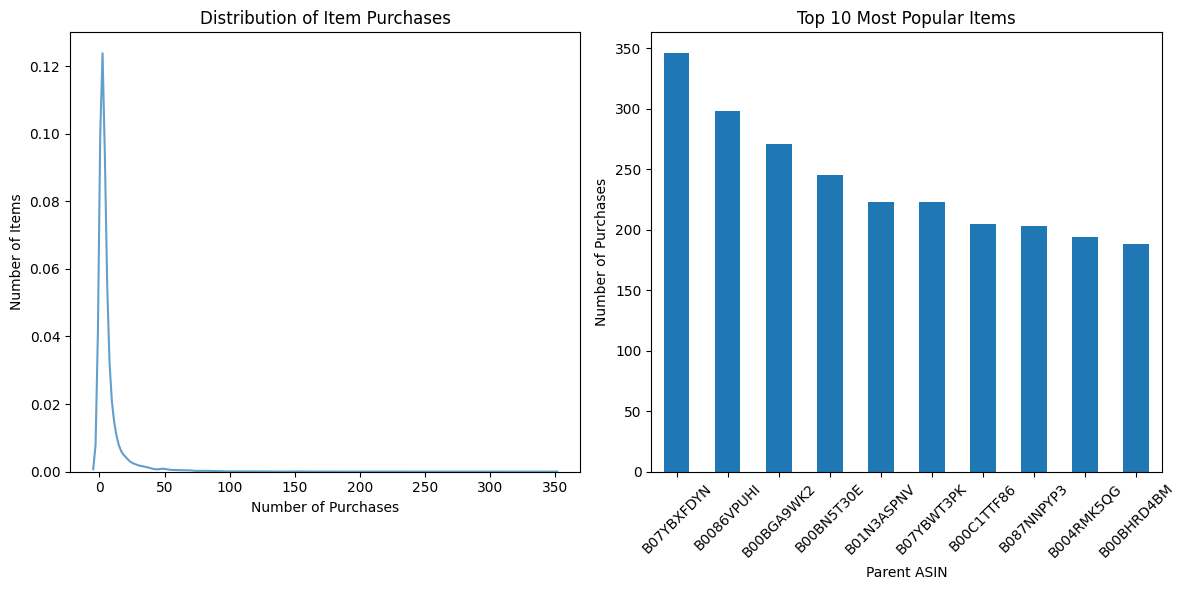


Item Purchase Distribution Statistics:
Mean purchases per item: 6.86
Median purchases per item: 3.00
Max purchases for an item: 346
Min purchases for an item: 1
Standard deviation: 13.96

User Statistics:
 Average purchases per user: 32.76
 Median purchases per user: 26.00
 Max purchases for a user: 473
 Min purchases for a user: 1
 Standard deviation: 22.80

Text Data Statistics:
Average tokens per item: 273.99
Max tokens for an item: 16034
Min tokens for an item: 10


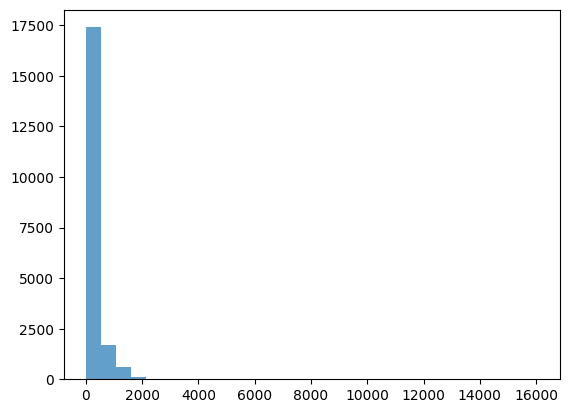

In [7]:
#Exploratory Data Analysis (EDA)
from matplotlib import pyplot as plt
import seaborn as sns
print(f"Number of unique items: {metadata_df.shape[0]}")
print(f"Number of unique users: {len(train_df['user_id'].unique())}")
print("Training set size: ", train_df.shape[0])
print("Training set unique items: ", train_df['parent_asin'].nunique())
print("Training set unique users: ", train_df['user_id'].nunique())
print("Test set size: ", test_df.shape[0])
print("Test set unique items: ", test_df['parent_asin'].nunique())
print("Test set unique users: ", test_df['user_id'].nunique())

# Distribution of item purchases (popularity)
item_purchase_counts = pd.concat([train_df['parent_asin'], test_df['parent_asin']]).value_counts()
top_items = item_purchase_counts.head(10)

# Plotting the distribution of item purchases
plt.figure(figsize=(12, 6))

# Plot histogram of item purchase counts
plt.subplot(1, 2, 1)
sns.kdeplot(item_purchase_counts, alpha=0.7)
plt.title('Distribution of Item Purchases')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Items')

# Plot top 10 most popular items
plt.subplot(1, 2, 2)
top_items.plot(kind='bar')
plt.title('Top 10 Most Popular Items')
plt.xlabel('Parent ASIN')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Basic statistics of purchase distribution
print("\nItem Purchase Distribution Statistics:")
print(f"Mean purchases per item: {item_purchase_counts.mean():.2f}")
print(f"Median purchases per item: {item_purchase_counts.median():.2f}")
print(f"Max purchases for an item: {item_purchase_counts.max()}")
print(f"Min purchases for an item: {item_purchase_counts.min()}")
print(f"Standard deviation: {item_purchase_counts.std():.2f}")

# Basic user statistics
print("\nUser Statistics:")
print(f" Average purchases per user: {train_df['user_id'].value_counts().mean():.2f}")
print(f" Median purchases per user: {train_df['user_id'].value_counts().median():.2f}")
print(f" Max purchases for a user: {train_df['user_id'].value_counts().max()}")
print(f" Min purchases for a user: {train_df['user_id'].value_counts().min()}")
print(f" Standard deviation: {train_df['user_id'].value_counts().std():.2f}")

# Check for text data statistics if available
if 'source_text' in metadata_df.columns:
    # Calculate token counts (approximation by word count)
    metadata_df['token_count'] = metadata_df['source_text'].str.split().str.len()
    
    print("\nText Data Statistics:")
    print(f"Average tokens per item: {metadata_df['token_count'].mean():.2f}")
    print(f"Max tokens for an item: {metadata_df['token_count'].max()}")
    print(f"Min tokens for an item: {metadata_df['token_count'].min()}")

plt.hist(metadata_df['token_count'], bins=30, alpha=0.7)
plt.show()

## 2. Experiment

In [6]:
EPOCH = "120"
TEST_BATCH_SIZE = "512"
BATCH_SIZE = "512"
N_CONTEXT_HOPS = "9"

### 2.1 Baseline - Collaborative Filtering 


Collaborative Filtering (CF) is a fundamental recommendation approach that predicts user preferences based on historical interaction patterns between users and items. It serves as an excellent baseline because it captures the core essence of recommendation systems by leveraging user-item interaction data without requiring additional contextual information, making it both computationally efficient and interpretable.


In [9]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]

sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--lr', "1e-3"])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    import mlflow
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    df_metric_convergence = pd.DataFrame(columns=["Epoch", "NDCG@20", "Recall@20", "Precision@20", "Hit_Ratio@20", "N_CONTEXT_HOPS"])
    df_outer_loss = pd.DataFrame()
   
    MODEL_TECHNIQUE = "collaborative_filtering"
    EXPERIMENT_NAME = "#1 Baseline Implementation - Full Taxonomy"
    mlflow.set_experiment(EXPERIMENT_NAME)
    EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
    os.makedirs(EXPERIMENT_DATA_PATH, exist_ok=True)
    sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])

    N_HOPS = [3,6,9,11]
    for N_CONTEXT_HOPS in N_HOPS:
        with mlflow.start_run(run_name=f"{DATASET}-Baseline-{MODEL_TECHNIQUE}-{N_CONTEXT_HOPS}-Hops"):
            mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
            mlflow.set_tag("dataset", DATASET)
            mlflow.log_param("batch_size", BATCH_SIZE)
            mlflow.log_param("epoch", EPOCH)
            mlflow.log_param("test_batch_size", TEST_BATCH_SIZE)

            data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
            metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
            train_df = pd.read_csv(data_path+'/train_df.csv')
            test_df = pd.read_csv(data_path+'/test_df.csv')
            build_kg = Build_KG()
            train_df = build_kg.user_item_triples(train_df)
            test_df = build_kg.user_item_triples(test_df)
            kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg_without_taxonomy(train_df, test_df,EXPERIMENT_DATA_PATH)
       
            """read args"""
            global args, device
            args = parse_args()
            sys.argv.extend(['--context_hops', str(N_CONTEXT_HOPS)])
            device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")
        
            """build dataset"""
            train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
            adj_mat_list, norm_mat_list, mean_mat_list = mat_list

            density = nx.density(graph)
            print(f"Density of the graph: {density}")
            avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
            print(f"Average degree of the graph: {avg_degree}")
            max_degree = max(dict(nx.degree(graph)).values())
            print(f"Max degree of the graph: {max_degree}")
            #gemma_avg_shortest_path_length = nx.average_shortest_path_length(graph)
            #print(f"Average shortest path length of the graph: {gemma_avg_shortest_path_length}")

            print(f"Dataset statistics:")
            print(f"Number of training interactions: {len(train_cf)}")
            print(f"Number of test interactions: {len(test_cf)}")
            print(f"Number of users: {n_params['n_users']}")
            print(f"Number of items: {n_params['n_items']}")
            #print(f"Batch size: {args.batch_size}")

            n_users = n_params['n_users']
            n_items = n_params['n_items']
            n_entities = n_params['n_entities']
            n_relations = n_params['n_relations']
            n_nodes = n_params['n_nodes']
            
            """cf data"""
            train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
            test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

            """define model"""
            augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
            model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
            
            """define optimizer"""
            rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
            aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
            model.augmenter = augmenter

            cur_best_pre_0 = 0
            stopping_step = 0
            should_stop = False
            total_iter = max(len(train_cf) // args.batch_size, 1)
            get_print = max(total_iter // 20, 1)
            
            print("start training ...")
            for epoch in range(args.epoch):
                # Add epoch start print
                print(f"\nEpoch {epoch+1}/{args.epoch}")
                print(f"Number of iterations expected: {total_iter}")
                
                index = np.arange(len(train_cf))
                np.random.shuffle(index)
                model.train()

                train_cf_pairs = train_cf_pairs[index]
                total_outer_loss, total_inner_loss, s = 0, 0, 0
                train_s_t = time()
                iteration = 0
                
                # Add batch processing print
                print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
                
                while s + args.batch_size <= len(train_cf):
                    batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
                    
                    # Debug print for first batch of first epoch
                    if epoch == 0 and iteration == 0:
                        print("\nFirst batch statistics:")
                        print(f"Users shape: {batch['users'].shape}")
                        print(f"Positive items shape: {batch['pos_items'].shape}")
                        print(f"Negative items shape: {batch['neg_items'].shape}")
                    
                    rec_loss, inv_mean, inv_var = model(batch)
                    outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
                    
                    # Debug print losses
                    if iteration % 100 == 0:
                        print(f"\nIteration {iteration} losses:")
                        print(f"rec_loss: {rec_loss.item():.6f}")
                        print(f"inv_mean: {inv_mean.item():.6f}")
                        print(f"inv_var: {inv_var.item():.6f}")
                        print(f"outer_loss: {outer_loss.item():.6f}")
                    
                    rec_optimizer.zero_grad()
                    outer_loss.backward()
                    
                    # Check gradients periodically
                    if iteration % 10 == 0:
                        print("\nGradient norms:")
                        for name, param in model.named_parameters():
                            if param.grad is not None:
                                grad_norm = param.grad.data.norm(2).item()
                                print(f"{name}: {grad_norm:.6f}")
                    
                    rec_optimizer.step()
                    total_outer_loss += outer_loss.item()

                    if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                        # Debug augmenter update
                        rec_loss, inv_mean, inv_var = model(batch)
                        inner_loss = - inv_var
                        
                        if iteration == 12:  # First augmenter update
                            print(f"\nAugmenter update:")
                            print(f"inner_loss: {inner_loss.item():.6f}")
                            print(f"inv_var: {inv_var.item():.6f}")
                        
                        aug_optimizer.zero_grad()
                        inner_loss.backward()
                        
                        # Debug augmenter gradients
                        if iteration == 12:
                            print("\nAugmenter gradient norms:")
                            for name, param in augmenter.named_parameters():
                                if param.grad is not None:
                                    print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                        
                        aug_optimizer.step()
                        total_inner_loss += inner_loss.item()

                    s += args.batch_size
                    iteration += 1
                    inner_loss = - inv_var
                    if iteration % get_print == 0:
                        print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                        .format(epoch + 1, args.epoch, 
                                iteration, total_iter, 
                                outer_loss.item(), 
                                inner_loss.item(),
                                (time() - train_s_t) / 60))

                train_e_t = time()
                print("-" * 100)
                print("start evluation ...")
                print("-" * 100)
                test_s_t = time()
                ret, predictions = test(model, user_dict, n_params)
                # save predictions
                predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_predictions.csv", index=False)

                test_e_t = time()
                epoch_outer_loss = total_outer_loss  / total_iter
                epoch_inner_loss = total_inner_loss  / total_iter
                train_time = (train_e_t - train_s_t) / 60
                test_time = (test_e_t - test_s_t) / 60
                
                # Create a pretty table for metrics
                metrics_table = PrettyTable()
                metrics_table.field_names = ["Metric", "Value"]
                
                # Add all available metrics
                for k_idx, k in enumerate(eval(args.Ks)):
                    metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
                    metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
                    metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
                    metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
                
                metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
                metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
                metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
                metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
                metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
                
                print("\nEvaluation Metrics:")
                print(metrics_table)
                print("-" * 100)

                # Convert PrettyTable to pandas DataFrame
                metrics_df = pd.DataFrame(metrics_table.rows, columns=metrics_table.field_names)
                os.makedirs(f"{EXPERIMENT_DATA_PATH}", exist_ok=True)
                metrics_df.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_acc_df.csv", index=False)

                
                # Keep the original print for consistency
                recall_20 = ret['recall'][0]
                ndcg_20 = ret['ndcg'][0]
                precision_20 = ret['precision'][0]
                hit_ratio_20 = ret['hit_ratio'][0]
                print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
                    .format(epoch + 1, args.epoch, 
                            epoch_outer_loss, epoch_inner_loss,
                            recall_20, ndcg_20,
                            train_time, test_time))
                print("-" * 100)

                recall_1000 = ret['recall'][4]
                ndcg_1000 = ret['ndcg'][4]
                precision_1000 = ret['precision'][4]
                hit_ratio_1000 = ret['hit_ratio'][4]

            # Append metrics for current epoch to convergence dataframe
                df_epoch_metrics = pd.DataFrame([{
                    "Epoch": epoch + 1,
                    "Recall@20": recall_20,
                    "NDCG@20": ndcg_20,
                    "Precision@20": precision_20,
                    "Hit_Ratio@20": hit_ratio_20,
                    "Recall@1000": recall_1000,
                    "NDCG@1000": ndcg_1000,
                    "Precision@1000": precision_1000,
                    "Hit_Ratio@1000": hit_ratio_1000,
                    "n_context_hops": N_CONTEXT_HOPS
                }])

                df_metric_convergence = pd.concat([df_metric_convergence, df_epoch_metrics], ignore_index=True)
                df_outer_loss = pd.concat([df_outer_loss, pd.DataFrame({
                        "Epoch": [epoch + 1],
                        "Outer Loss": [epoch_outer_loss],
                        "n_context_hops": [N_CONTEXT_HOPS]
                    })], ignore_index=True)

        # --- MLflow Parameter Logging ---
        print("Logging parameters to MLflow...")
        mlflow.log_param("model_technique", MODEL_TECHNIQUE)
        mlflow.log_param("context_hops", N_CONTEXT_HOPS)
        mlflow.set_tag("dataset", DATASET)
        mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
        mlflow.set_tag("model_technique", MODEL_TECHNIQUE)
        mlflow.log_metric("precision_20", precision_20)
        mlflow.log_metric("hit_ratio_20", hit_ratio_20)
        mlflow.log_metric("recall_20", recall_20)
        mlflow.log_metric("ndcg_20", ndcg_20)
        mlflow.log_metric("auc", f"{ret['auc']:.4f}")
        mlflow.log_metric("train_time", f"{train_time:.2f}")
        mlflow.log_metric("test_time", f"{test_time:.2f}")
        mlflow.log_metric("max_path_length", f"{max_degree:.2f}")
        mlflow.log_metric("density", f"{density:.2f}")
        mlflow.end_run()
    # make plot of df_metric_convergence
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@20", label="NDCG@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@20", label="Recall@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@20", label="Precision@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@20", label="Hit_Ratio@20")
        plt.title("Metrics@20 Convergence")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Value")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric@20_convergence.png")
            # make plot of df_metric_convergence
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@1000", label="NDCG@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@1000", label="Recall@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@1000", label="Precision@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@1000", label="Hit_Ratio@1000")
        plt.title("Metrics@100 Convergence")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Value")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric@100_convergence.png")

        # make plot of df_outer_loss
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_outer_loss, x="Epoch", y="Outer Loss", label="Outer Loss")
        plt.title(f"Loss Convergence for {MODEL_TECHNIQUE} with {N_CONTEXT_HOPS} Hops")
        plt.xlabel("Epoch")
        plt.ylabel("BPR Loss")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_outer_loss_convergence.png")


Ignoring unrecognized arguments: ['--f=/Users/U725801/Library/Jupyter/runtime/kernel-v31d81edc5d0cfbad4072c272ba6a7f56b42095429.json']
Ignoring unrecognized arguments: ['--f=/Users/U725801/Library/Jupyter/runtime/kernel-v31d81edc5d0cfbad4072c272ba6a7f56b42095429.json']


2025/07/06 10:31:27 INFO mlflow.tracking.fluent: Experiment with name '#1 Baseline Implementation - Full Taxonomy' does not exist. Creating a new experiment.


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation - Full Taxonomy/amazon-Video_Games/collaborative_filtering
Combined KG has 136080 unique triples.
Found 23876 unique entities.
Found 1 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 136080 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation - Full Taxonomy/amazon-Video_Games/collaborative_filtering/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation - Full Taxonomy/amazon-Video_Games/collaborative_filtering/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation - Full Taxonomy/amazon-Video_Games/collaborative_filtering/kg_final.txt
Saved 

100%|##########| 3990/3990 [00:00<00:00, 1457268.63it/s]



Begin to load knowledge graph triples ...


100%|##########| 272160/272160 [00:00<00:00, 339173.23it/s]


End to build graph ... MultiDiGraph with 23876 nodes and 272160 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 3/3 [00:00<00:00, 48.61it/s]


Density of the graph: 0.00047744059841467126
Average degree of the graph: 22.797788574300554
Max degree of the graph: 946
Dataset statistics:
Number of training interactions: 3990
Number of test interactions: 813
Number of users: 4047
Number of items: 23853
start training ...

Epoch 1/120
Number of iterations expected: 7
Processing 3990 samples in batches of 512

First batch statistics:
Users shape: torch.Size([512])
Positive items shape: torch.Size([512])
Negative items shape: torch.Size([512])

Iteration 0 losses:
rec_loss: 0.427229
inv_mean: 2.243510
inv_var: 0.000174
outer_loss: 0.449666

Gradient norms:
all_embed: 0.635230
latent_emb: 0.000047
gcn.weight: 0.099826
gcn.disen_weight_att: 0.000516
gcn.invariant_generator.kg_W_r: 0.000001
augmenter.edge_mlp_list.0.0.weight: 0.000014
augmenter.edge_mlp_list.0.0.bias: 0.000009
augmenter.edge_mlp_list.0.2.weight: 0.000004
augmenter.edge_mlp_list.0.2.bias: 0.000003
augmenter.edge_mlp_list.1.0.weight: 0.000028
augmenter.edge_mlp_list.1.0.b

KeyboardInterrupt: 

### 2.2 Baseline - Flat attributes

This baseline uses the flat attributes from items, for instance price, store or other. This help draw connection but dont follow hierarchical structure



In [ ]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--lr', "1e-3"])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    import mlflow
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    df_metric_convergence = pd.DataFrame(columns=["Epoch", "NDCG@20", "Recall@20", "Precision@20", "Hit_Ratio@20", "N_CONTEXT_HOPS"])
    df_outer_loss = pd.DataFrame()

    MODEL_TECHNIQUE = "baseline_flat"
    EXPERIMENT_NAME = "#1 Baseline Implementation"
    mlflow.set_experiment(EXPERIMENT_NAME)
    EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
    sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])

    N_HOPS = [3,6,9,11]
    for N_CONTEXT_HOPS in N_HOPS:
        with mlflow.start_run(run_name=f"{DATASET}-Baseline-{MODEL_TECHNIQUE}-{N_CONTEXT_HOPS}-Hops"):
            mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
            mlflow.set_tag("dataset", DATASET)
            mlflow.log_param("batch_size", BATCH_SIZE)
            mlflow.log_param("epoch", EPOCH)
            mlflow.log_param("test_batch_size", TEST_BATCH_SIZE)


            

            triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
            flat_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}.csv')
            data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
            metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
            train_df = pd.read_csv(data_path+'/train_df.csv')
            test_df = pd.read_csv(data_path+'/test_df.csv')
            build_kg = Build_KG()
            train_df = build_kg.user_item_triples(train_df)
            test_df = build_kg.user_item_triples(test_df)
            kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(flat_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)

       
            """read args"""
            global args, device
            args = parse_args()
            sys.argv.extend(['--context_hops', str(N_CONTEXT_HOPS)])
            device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")
        
            """build dataset"""
            train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
            adj_mat_list, norm_mat_list, mean_mat_list = mat_list

            density = nx.density(graph)
            print(f"Density of the graph: {density}")
            avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
            print(f"Average degree of the graph: {avg_degree}")
            max_degree = max(dict(nx.degree(graph)).values())
            print(f"Max degree of the graph: {max_degree}")
            #gemma_avg_shortest_path_length = nx.average_shortest_path_length(graph)
            #print(f"Average shortest path length of the graph: {gemma_avg_shortest_path_length}")

            print(f"Dataset statistics:")
            print(f"Number of training interactions: {len(train_cf)}")
            print(f"Number of test interactions: {len(test_cf)}")
            print(f"Number of users: {n_params['n_users']}")
            print(f"Number of items: {n_params['n_items']}")
            #print(f"Batch size: {args.batch_size}")

            n_users = n_params['n_users']
            n_items = n_params['n_items']
            n_entities = n_params['n_entities']
            n_relations = n_params['n_relations']
            n_nodes = n_params['n_nodes']
            
            """cf data"""
            train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
            test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

            """define model"""
            augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
            model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
            
            """define optimizer"""
            rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
            aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
            model.augmenter = augmenter

            cur_best_pre_0 = 0
            stopping_step = 0
            should_stop = False
            total_iter = max(len(train_cf) // args.batch_size, 1)
            get_print = max(total_iter // 20, 1)
            
            print("start training ...")
            for epoch in range(args.epoch):
                # Add epoch start print
                print(f"\nEpoch {epoch+1}/{args.epoch}")
                print(f"Number of iterations expected: {total_iter}")
                
                index = np.arange(len(train_cf))
                np.random.shuffle(index)
                model.train()

                train_cf_pairs = train_cf_pairs[index]
                total_outer_loss, total_inner_loss, s = 0, 0, 0
                train_s_t = time()
                iteration = 0
                
                # Add batch processing print
                print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
                
                while s + args.batch_size <= len(train_cf):
                    batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
                    
                    # Debug print for first batch of first epoch
                    if epoch == 0 and iteration == 0:
                        print("\nFirst batch statistics:")
                        print(f"Users shape: {batch['users'].shape}")
                        print(f"Positive items shape: {batch['pos_items'].shape}")
                        print(f"Negative items shape: {batch['neg_items'].shape}")
                    
                    rec_loss, inv_mean, inv_var = model(batch)
                    outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
                    
                    # Debug print losses
                    if iteration % 100 == 0:
                        print(f"\nIteration {iteration} losses:")
                        print(f"rec_loss: {rec_loss.item():.6f}")
                        print(f"inv_mean: {inv_mean.item():.6f}")
                        print(f"inv_var: {inv_var.item():.6f}")
                        print(f"outer_loss: {outer_loss.item():.6f}")
                    
                    rec_optimizer.zero_grad()
                    outer_loss.backward()
                    
                    # Check gradients periodically
                    if iteration % 10 == 0:
                        print("\nGradient norms:")
                        for name, param in model.named_parameters():
                            if param.grad is not None:
                                grad_norm = param.grad.data.norm(2).item()
                                print(f"{name}: {grad_norm:.6f}")
                    
                    rec_optimizer.step()
                    total_outer_loss += outer_loss.item()

                    if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                        # Debug augmenter update
                        rec_loss, inv_mean, inv_var = model(batch)
                        inner_loss = - inv_var
                        
                        if iteration == 12:  # First augmenter update
                            print(f"\nAugmenter update:")
                            print(f"inner_loss: {inner_loss.item():.6f}")
                            print(f"inv_var: {inv_var.item():.6f}")
                        
                        aug_optimizer.zero_grad()
                        inner_loss.backward()
                        
                        # Debug augmenter gradients
                        if iteration == 12:
                            print("\nAugmenter gradient norms:")
                            for name, param in augmenter.named_parameters():
                                if param.grad is not None:
                                    print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                        
                        aug_optimizer.step()
                        total_inner_loss += inner_loss.item()

                    s += args.batch_size
                    iteration += 1
                    inner_loss = - inv_var
                    if iteration % get_print == 0:
                        print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                        .format(epoch + 1, args.epoch, 
                                iteration, total_iter, 
                                outer_loss.item(), 
                                inner_loss.item(),
                                (time() - train_s_t) / 60))

                train_e_t = time()
                print("-" * 100)
                print("start evluation ...")
                print("-" * 100)
                test_s_t = time()
                ret, predictions = test(model, user_dict, n_params)
                # save predictions
                predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_predictions.csv", index=False)

                test_e_t = time()
                epoch_outer_loss = total_outer_loss  / total_iter
                epoch_inner_loss = total_inner_loss  / total_iter
                train_time = (train_e_t - train_s_t) / 60
                test_time = (test_e_t - test_s_t) / 60
                
                # Create a pretty table for metrics
                metrics_table = PrettyTable()
                metrics_table.field_names = ["Metric", "Value"]
                
                # Add all available metrics
                for k_idx, k in enumerate(eval(args.Ks)):
                    metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
                    metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
                    metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
                    metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
                
                metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
                metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
                metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
                metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
                metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
                
                print("\nEvaluation Metrics:")
                print(metrics_table)
                print("-" * 100)

                # Convert PrettyTable to pandas DataFrame
                metrics_df = pd.DataFrame(metrics_table.rows, columns=metrics_table.field_names)
                os.makedirs(f"{EXPERIMENT_DATA_PATH}", exist_ok=True)
                metrics_df.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_acc_df.csv", index=False)

                
                # Keep the original print for consistency
                recall_20 = ret['recall'][0]
                ndcg_20 = ret['ndcg'][0]
                precision_20 = ret['precision'][0]
                hit_ratio_20 = ret['hit_ratio'][0]
                print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
                    .format(epoch + 1, args.epoch, 
                            epoch_outer_loss, epoch_inner_loss,
                            recall_20, ndcg_20,
                            train_time, test_time))
                print("-" * 100)

                recall_1000 = ret['recall'][4]
                ndcg_1000 = ret['ndcg'][4]
                precision_1000 = ret['precision'][4]
                hit_ratio_1000 = ret['hit_ratio'][4]

            # Append metrics for current epoch to convergence dataframe
                df_epoch_metrics = pd.DataFrame([{
                    "Epoch": epoch + 1,
                    "Recall@20": recall_20,
                    "NDCG@20": ndcg_20,
                    "Precision@20": precision_20,
                    "Hit_Ratio@20": hit_ratio_20,
                    "Recall@1000": recall_1000,
                    "NDCG@1000": ndcg_1000,
                    "Precision@1000": precision_1000,
                    "Hit_Ratio@1000": hit_ratio_1000,
                    "n_context_hops": N_CONTEXT_HOPS
                }])

                df_metric_convergence = pd.concat([df_metric_convergence, df_epoch_metrics], ignore_index=True)
                df_outer_loss = pd.concat([df_outer_loss, pd.DataFrame({
                        "Epoch": [epoch + 1],
                        "Outer Loss": [epoch_outer_loss],
                        "n_context_hops": [N_CONTEXT_HOPS]
                    })], ignore_index=True)

        # --- MLflow Parameter Logging ---
        print("Logging parameters to MLflow...")
        mlflow.log_param("model_technique", MODEL_TECHNIQUE)
        mlflow.log_param("context_hops", N_CONTEXT_HOPS)
        mlflow.set_tag("dataset", DATASET)
        mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
        mlflow.set_tag("model_technique", MODEL_TECHNIQUE)
        mlflow.log_metric("precision_20", precision_20)
        mlflow.log_metric("hit_ratio_20", hit_ratio_20)
        mlflow.log_metric("recall_20", recall_20)
        mlflow.log_metric("ndcg_20", ndcg_20)
        mlflow.log_metric("auc", f"{ret['auc']:.4f}")
        mlflow.log_metric("train_time", f"{train_time:.2f}")
        mlflow.log_metric("test_time", f"{test_time:.2f}")
        mlflow.log_metric("max_path_length", f"{max_degree:.2f}")
        mlflow.log_metric("density", f"{density:.2f}")
        mlflow.end_run()
    # make plot of df_metric_convergence
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@20", label="NDCG@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@20", label="Recall@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@20", label="Precision@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@20", label="Hit_Ratio@20")
        plt.title("Metrics@20 Convergence")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Value")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric@20_convergence.png")
            # make plot of df_metric_convergence
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@1000", label="NDCG@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@1000", label="Recall@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@1000", label="Precision@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@1000", label="Hit_Ratio@1000")
        plt.title("Metrics@100 Convergence")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Value")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric@100_convergence.png")

        # make plot of df_outer_loss
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_outer_loss, x="Epoch", y="Outer Loss", label="Outer Loss")
        plt.title("Loss Convergence")
        plt.xlabel("Epoch")
        plt.ylabel("BPR Loss")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_outer_loss_convergence.png")


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation/amazon-Video_Games/baseline_flat
Combined KG has 174539 unique triples.
Found 25458 unique entities.
Found 2 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 174539 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation/amazon-Video_Games/baseline_flat/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation/amazon-Video_Games/baseline_flat/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation/amazon-Video_Games/baseline_flat/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Im

100%|##########| 3990/3990 [00:00<00:00, 1699357.53it/s]



Begin to load knowledge graph triples ...


100%|##########| 349078/349078 [00:07<00:00, 45009.85it/s]


End to build graph ... MultiDiGraph with 25458 nodes and 349078 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...


Begin to load knowledge graph triples ...


100%|##########| 349078/349078 [00:00<00:00, 392253.32it/s]


End to build graph ... MultiDiGraph with 25458 nodes and 349078 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 5/5 [00:00<00:00, 60.16it/s]


Density of the graph: 0.0005386305404531737
Average degree of the graph: 27.423835336632887
Max degree of the graph: 12620
Dataset statistics:
Number of training interactions: 3990
Number of test interactions: 813
Number of users: 4047
Number of items: 23839
start training ...

Epoch 1/120
Number of iterations expected: 7
Processing 3990 samples in batches of 512

First batch statistics:
Users shape: torch.Size([512])
Positive items shape: torch.Size([512])
Negative items shape: torch.Size([512])

Iteration 0 losses:
rec_loss: 0.365615
inv_mean: 2.865372
inv_var: 0.012330
outer_loss: 0.394392

Gradient norms:
all_embed: 1.966869
latent_emb: 0.000212
gcn.weight: 0.217544
gcn.disen_weight_att: 0.000546
gcn.invariant_generator.kg_W_r: 0.000003
augmenter.edge_mlp_list.0.0.weight: 0.000066
augmenter.edge_mlp_list.0.0.bias: 0.000039
augmenter.edge_mlp_list.0.2.weight: 0.000019
augmenter.edge_mlp_list.0.2.bias: 0.000021
augmenter.edge_mlp_list.1.0.weight: 0.000025
augmenter.edge_mlp_list.1.0.

### 2.3 LLM-Col-Hierarchy-Tax (Gemma 3)


In [4]:
DATASET = DATASETS[2]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[3].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [7]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender
import matplotlib.pyplot as plt

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--lr', "1e-3"])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    import mlflow
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    df_metric_convergence = pd.DataFrame(columns=["Epoch", "NDCG@20", "Recall@20", "Precision@20", "Hit_Ratio@20", "N_CONTEXT_HOPS"])
    df_outer_loss = pd.DataFrame()

    MODEL_TECHNIQUE = "gemma3"
    EXPERIMENT_NAME = "#1 Baseline Implementation"
    mlflow.set_experiment(EXPERIMENT_NAME)
    EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
    sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])

    N_HOPS = [3,6,9,11]
    for N_CONTEXT_HOPS in N_HOPS:
        with mlflow.start_run(run_name=f"{DATASET}-Baseline-{MODEL_TECHNIQUE}-{N_CONTEXT_HOPS}-Hops"):
            mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
            mlflow.set_tag("dataset", DATASET)
            mlflow.log_param("batch_size", BATCH_SIZE)
            mlflow.log_param("epoch", EPOCH)
            mlflow.log_param("test_batch_size", TEST_BATCH_SIZE)
    

            triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
            gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-triples-full1.csv')
            data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
            metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
            train_df = pd.read_csv(data_path+'/train_df.csv')
            test_df = pd.read_csv(data_path+'/test_df.csv')
            build_kg = Build_KG()
            train_df = build_kg.user_item_triples(train_df)
            test_df = build_kg.user_item_triples(test_df)
            kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(gemma_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)

       
            """read args"""
            global args, device
            args = parse_args()
            sys.argv.extend(['--context_hops', str(N_CONTEXT_HOPS)])
            device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")
        
            """build dataset"""
            train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
            adj_mat_list, norm_mat_list, mean_mat_list = mat_list

            density = nx.density(graph)
            print(f"Density of the graph: {density}")
            avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
            print(f"Average degree of the graph: {avg_degree}")
            max_degree = max(dict(nx.degree(graph)).values())
            print(f"Max degree of the graph: {max_degree}")
            #gemma_avg_shortest_path_length = nx.average_shortest_path_length(graph)
            #print(f"Average shortest path length of the graph: {gemma_avg_shortest_path_length}")

            print(f"Dataset statistics:")
            print(f"Number of training interactions: {len(train_cf)}")
            print(f"Number of test interactions: {len(test_cf)}")
            print(f"Number of users: {n_params['n_users']}")
            print(f"Number of items: {n_params['n_items']}")
            #print(f"Batch size: {args.batch_size}")

            n_users = n_params['n_users']
            n_items = n_params['n_items']
            n_entities = n_params['n_entities']
            n_relations = n_params['n_relations']
            n_nodes = n_params['n_nodes']
            
            """cf data"""
            train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
            test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

            """define model"""
            augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
            model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
            
            """define optimizer"""
            rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
            aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
            model.augmenter = augmenter

            cur_best_pre_0 = 0
            stopping_step = 0
            should_stop = False
            total_iter = max(len(train_cf) // args.batch_size, 1)
            get_print = max(total_iter // 20, 1)
            
            print("start training ...")
            for epoch in range(args.epoch):
                # Add epoch start print
                print(f"\nEpoch {epoch+1}/{args.epoch}")
                print(f"Number of iterations expected: {total_iter}")
                
                index = np.arange(len(train_cf))
                np.random.shuffle(index)
                model.train()

                train_cf_pairs = train_cf_pairs[index]
                total_outer_loss, total_inner_loss, s = 0, 0, 0
                train_s_t = time()
                iteration = 0
                
                # Add batch processing print
                print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
                
                while s + args.batch_size <= len(train_cf):
                    batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
                    
                    # Debug print for first batch of first epoch
                    if epoch == 0 and iteration == 0:
                        print("\nFirst batch statistics:")
                        print(f"Users shape: {batch['users'].shape}")
                        print(f"Positive items shape: {batch['pos_items'].shape}")
                        print(f"Negative items shape: {batch['neg_items'].shape}")
                    
                    rec_loss, inv_mean, inv_var = model(batch)
                    outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
                    
                    # Debug print losses
                    if iteration % 100 == 0:
                        print(f"\nIteration {iteration} losses:")
                        print(f"rec_loss: {rec_loss.item():.6f}")
                        print(f"inv_mean: {inv_mean.item():.6f}")
                        print(f"inv_var: {inv_var.item():.6f}")
                        print(f"outer_loss: {outer_loss.item():.6f}")
                    
                    rec_optimizer.zero_grad()
                    outer_loss.backward()
                    
                    # Check gradients periodically
                    if iteration % 10 == 0:
                        print("\nGradient norms:")
                        for name, param in model.named_parameters():
                            if param.grad is not None:
                                grad_norm = param.grad.data.norm(2).item()
                                print(f"{name}: {grad_norm:.6f}")
                    
                    rec_optimizer.step()
                    total_outer_loss += outer_loss.item()

                    if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                        # Debug augmenter update
                        rec_loss, inv_mean, inv_var = model(batch)
                        inner_loss = - inv_var
                        
                        if iteration == 12:  # First augmenter update
                            print(f"\nAugmenter update:")
                            print(f"inner_loss: {inner_loss.item():.6f}")
                            print(f"inv_var: {inv_var.item():.6f}")
                        
                        aug_optimizer.zero_grad()
                        inner_loss.backward()
                        
                        # Debug augmenter gradients
                        if iteration == 12:
                            print("\nAugmenter gradient norms:")
                            for name, param in augmenter.named_parameters():
                                if param.grad is not None:
                                    print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                        
                        aug_optimizer.step()
                        total_inner_loss += inner_loss.item()

                    s += args.batch_size
                    iteration += 1
                    inner_loss = - inv_var
                    if iteration % get_print == 0:
                        print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                        .format(epoch + 1, args.epoch, 
                                iteration, total_iter, 
                                outer_loss.item(), 
                                inner_loss.item(),
                                (time() - train_s_t) / 60))

                train_e_t = time()
                print("-" * 100)
                print("start evluation ...")
                print("-" * 100)
                test_s_t = time()
                ret, predictions = test(model, user_dict, n_params)
                # save predictions
                predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_predictions.csv", index=False)

                test_e_t = time()
                epoch_outer_loss = total_outer_loss  / total_iter
                epoch_inner_loss = total_inner_loss  / total_iter
                train_time = (train_e_t - train_s_t) / 60
                test_time = (test_e_t - test_s_t) / 60
                
                # Create a pretty table for metrics
                metrics_table = PrettyTable()
                metrics_table.field_names = ["Metric", "Value"]
                
                # Add all available metrics
                for k_idx, k in enumerate(eval(args.Ks)):
                    metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
                    metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
                    metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
                    metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
                
                metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
                metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
                metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
                metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
                metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
                
                print("\nEvaluation Metrics:")
                print(metrics_table)
                print("-" * 100)

                # Convert PrettyTable to pandas DataFrame
                metrics_df = pd.DataFrame(metrics_table.rows, columns=metrics_table.field_names)
                os.makedirs(f"{EXPERIMENT_DATA_PATH}", exist_ok=True)
                metrics_df.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_acc_df.csv", index=False)

                
                # Keep the original print for consistency
                recall_20 = ret['recall'][0]
                ndcg_20 = ret['ndcg'][0]
                precision_20 = ret['precision'][0]
                hit_ratio_20 = ret['hit_ratio'][0]
                print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
                    .format(epoch + 1, args.epoch, 
                            epoch_outer_loss, epoch_inner_loss,
                            recall_20, ndcg_20,
                            train_time, test_time))
                print("-" * 100)

                recall_1000 = ret['recall'][4]
                ndcg_1000 = ret['ndcg'][4]
                precision_1000 = ret['precision'][4]
                hit_ratio_1000 = ret['hit_ratio'][4]

            # Append metrics for current epoch to convergence dataframe
                df_epoch_metrics = pd.DataFrame([{
                    "Epoch": epoch + 1,
                    "Recall@20": recall_20,
                    "NDCG@20": ndcg_20,
                    "Precision@20": precision_20,
                    "Hit_Ratio@20": hit_ratio_20,
                    "Recall@1000": recall_1000,
                    "NDCG@1000": ndcg_1000,
                    "Precision@1000": precision_1000,
                    "Hit_Ratio@1000": hit_ratio_1000,
                    "n_context_hops": N_CONTEXT_HOPS
                }])

                df_metric_convergence = pd.concat([df_metric_convergence, df_epoch_metrics], ignore_index=True)
                df_outer_loss = pd.concat([df_outer_loss, pd.DataFrame({
                        "Epoch": [epoch + 1],
                        "Outer Loss": [epoch_outer_loss],
                        "n_context_hops": [N_CONTEXT_HOPS]
                    })], ignore_index=True)

        # --- MLflow Parameter Logging ---
        print("Logging parameters to MLflow...")
        mlflow.log_param("model_technique", MODEL_TECHNIQUE)
        mlflow.log_param("context_hops", N_CONTEXT_HOPS)
        mlflow.set_tag("dataset", DATASET)
        mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
        mlflow.set_tag("model_technique", MODEL_TECHNIQUE)
        mlflow.log_metric("precision_20", precision_20)
        mlflow.log_metric("hit_ratio_20", hit_ratio_20)
        mlflow.log_metric("recall_20", recall_20)
        mlflow.log_metric("ndcg_20", ndcg_20)
        mlflow.log_metric("auc", f"{ret['auc']:.4f}")
        mlflow.log_metric("train_time", f"{train_time:.2f}")
        mlflow.log_metric("test_time", f"{test_time:.2f}")
        mlflow.log_metric("max_path_length", f"{max_degree:.2f}")
        mlflow.log_metric("density", f"{density:.2f}")
        mlflow.end_run()
    # make plot of df_metric_convergence
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@20", label="NDCG@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@20", label="Recall@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@20", label="Precision@20")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@20", label="Hit_Ratio@20")
        plt.title("Metrics@20 Convergence")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Value")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{str(N_CONTEXT_HOPS)}-Hops_metric@20_convergence.png")
            # make plot of df_metric_convergence
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@1000", label="NDCG@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@1000", label="Recall@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@1000", label="Precision@1000")
        sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@1000", label="Hit_Ratio@1000")
        plt.title("Metrics@100 Convergence")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Value")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{str(N_CONTEXT_HOPS)}-Hops_metric@100_convergence.png")

        # make plot of df_outer_loss
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_outer_loss, x="Epoch", y="Outer Loss", label="Outer Loss")
        plt.title("Loss Convergence for "+{MODEL_TECHNIQUE})
        plt.xlabel("Epoch")
        plt.ylabel("BPR Loss")
        plt.legend()
        plt.savefig(f"{EXPERIMENT_DATA_PATH}/{str(N_CONTEXT_HOPS)}-Hops_outer_loss_convergence.png")


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation - Full Taxonomy/amazon-Video_Games/gemma3
Combined KG has 468233 unique triples.
Found 24031 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 332153 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation - Full Taxonomy/amazon-Video_Games/gemma3/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation - Full Taxonomy/amazon-Video_Games/gemma3/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation - Full Taxonomy/amazon-Video_Games/gemma3/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playgr

100%|##########| 3990/3990 [00:00<00:00, 1479426.53it/s]



Begin to load knowledge graph triples ...


100%|##########| 664306/664306 [00:01<00:00, 379849.14it/s]


End to build graph ... MultiDiGraph with 19399 nodes and 664306 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 5/5 [00:00<00:00, 37.79it/s]


Density of the graph: 0.0017653542886834222
Average degree of the graph: 68.48868498376206
Max degree of the graph: 22888
Dataset statistics:
Number of training interactions: 3990
Number of test interactions: 813
Number of users: 4047
Number of items: 23877
start training ...

Epoch 1/120
Number of iterations expected: 7
Processing 3990 samples in batches of 512

First batch statistics:
Users shape: torch.Size([512])
Positive items shape: torch.Size([512])
Negative items shape: torch.Size([512])

Iteration 0 losses:
rec_loss: 0.456582
inv_mean: 2.479771
inv_var: 0.000384
outer_loss: 0.481383

Gradient norms:
all_embed: 1.333626
latent_emb: 0.000038
gcn.weight: 0.089315
gcn.disen_weight_att: 0.000438
gcn.invariant_generator.kg_W_r: 0.000001
augmenter.edge_mlp_list.0.0.weight: 0.000009
augmenter.edge_mlp_list.0.0.bias: 0.000006
augmenter.edge_mlp_list.0.2.weight: 0.000002
augmenter.edge_mlp_list.0.2.bias: 0.000004
augmenter.edge_mlp_list.1.0.weight: 0.000022
augmenter.edge_mlp_list.1.0.b

NameError: name 'plt' is not defined

## 3. Results

In [169]:
!mlflow ui

[2025-05-14 10:01:02 -0400] [12397] [INFO] Starting gunicorn 23.0.0
[2025-05-14 10:01:02 -0400] [12397] [INFO] Listening at: http://127.0.0.1:5000 (12397)
[2025-05-14 10:01:02 -0400] [12397] [INFO] Using worker: sync
[2025-05-14 10:01:02 -0400] [12400] [INFO] Booting worker with pid: 12400
[2025-05-14 10:01:02 -0400] [12401] [INFO] Booting worker with pid: 12401
[2025-05-14 10:01:02 -0400] [12402] [INFO] Booting worker with pid: 12402
[2025-05-14 10:01:02 -0400] [12405] [INFO] Booting worker with pid: 12405


## 3. Interpretation and Discussion